# Create Your Own Analytics: Football · NFL
 **SAC UTD · Workshop 2 · Student notebook**

 ## Goal
 Can recent form help predict a team's next game? What groups of teams appear when we look across a season?

 Choose a sport; learn **all four methods**: linear regression, logistic classification, K-Means clustering, and principal component analysis (PCA).
 Like Workshop 1, the first examples are provided. Then you edit a working experiment, fill in short tasks, and finish with your own analysis.

 | Stage | Your role |
 |---|---|
 | Setup and explore | Run provided code; inspect the data |
 | Regression and classification | Run examples; change inputs and thresholds |
 | Clustering and PCA | Choose settings; interpret the patterns |
 | CYOA | Ask a question; build evidence; tell a supported story |

 Suggested pace: 10 min setup, 15 regression, 15 classification, 15 clustering/PCA, 20–30 CYOA. Beginners can use two sessions.

 **Before running:** download `nfl_data.csv` from the accompanying `data/` folder. Open this notebook in Google Colab using **File → Upload notebook**, connect a CPU runtime, then run cells in order. No API key is needed.

## Setup
 Colab includes these packages. Locally, install the supplied `requirements.txt`. If an import fails in Colab, run `%pip install pandas numpy matplotlib scikit-learn` in a new cell, then restart the runtime. Outputs below are saved examples; rerun after changing code.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import mean_absolute_error, accuracy_score, balanced_accuracy_score, classification_report, ConfusionMatrixDisplay, silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

SEED = 42
plt.rcParams.update({'figure.figsize': (8, 4.8), 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

### Upload the data
 Use the file picker if the CSV is not already beside the notebook. Locally, an extracted bundle also works with `../data/`. The supplied CSV is an unchanged copy of [Workshop 1](https://github.com/Sports-Analytics-Club-at-UTD/Workshop-1-Sports-Analytics-Storytelling). This notebook does not call a live sports API.

In [2]:
filename = 'nfl_data.csv'
candidates = [Path(filename), Path('../data') / filename, Path('data') / filename]
data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    try:
        from google.colab import files
    except ImportError:
        raise FileNotFoundError(f'Place {filename} beside this notebook or in ../data/')
    uploaded = files.upload()
    if filename not in uploaded:
        raise ValueError(f'Upload the file named {filename}')
    data_path = Path(filename)
raw = pd.read_csv(data_path)
print(f'Loaded {len(raw):,} source rows and {len(raw.columns)} columns.')
display(raw.head())

Loaded 5,357 source rows and 15 columns.


,season,week,game_id,team,opponent,is_home,team_score,opp_score,win,total_yards,opp_total_yards,yard_margin,turnovers,opp_turnovers,turnover_margin
0,2015,1,2015_01_BAL_DEN,BAL,DEN,False,13.0,19.0,False,173.0,219.0,-46.0,2,1.0,-1.0
1,2015,1,2015_01_BAL_DEN,DEN,BAL,True,19.0,13.0,True,219.0,173.0,46.0,1,2.0,1.0
2,2015,1,2015_01_CAR_JAX,CAR,JAX,False,20.0,9.0,True,263.0,265.0,-2.0,1,3.0,2.0
3,2015,1,2015_01_CAR_JAX,JAX,CAR,True,9.0,20.0,False,265.0,263.0,2.0,3,1.0,-2.0
4,2015,1,2015_01_CIN_OAK,CIN,OAK,False,33.0,13.0,True,396.0,NaN,NaN,0,NaN,NaN


## 1. Explore and prepare
 One row is one team in one game. team_score/opp_score are points scored/allowed; total_yards/opp_total_yards measure yards gained/allowed. turnovers/opp_turnovers are giveaways/takeaways. This export has no game dates or run/pass counts. We order games by season and week; ties count as not a win. Current-game yards and turnovers are only used for historical summaries, never directly to predict that game.

 We use **team-game rows** for prediction and **team-season rows** for unsupervised exploration. Read the preparation once; it is provided so you can focus on modeling.

In [3]:
games = raw.rename(columns={'team_score':'score', 'opp_score':'allowed'}).copy()
games['season'] = games['season'].astype(str)
# No date field: season + week provides the chronology in this export.
games['date'] = games['week']
games['is_home'] = games['is_home'].astype(int)

games = games.dropna(subset=['score', 'allowed']).copy()
games['win_target'] = (games['score'] > games['allowed']).astype(int)
games['margin'] = games['score'] - games['allowed']
games = games.sort_values(['season', 'date', 'game_id', 'team']).reset_index(drop=True)
assert not games.duplicated(['game_id', 'team']).any(), 'Duplicate team-game rows'
print('Seasons:', sorted(games['season'].astype(str).unique()))
print('Modeling rows:', len(games), '| teams:', games['team'].nunique())
print('Missing values:')
display(games[['score', 'allowed', 'is_home']].isna().sum().to_frame('missing'))
display(games.groupby('season').agg(team_games=('team','size'), mean_score=('score','mean')).round(2))

Seasons: ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
Modeling rows: 5357 | teams: 32
Missing values:


,missing
score,0
allowed,0
is_home,0


,team_games,mean_score
season,,
2015,486,23.00
2016,501,22.70
2017,518,21.91
2018,518,23.43
2019,518,22.95
2020,538,24.75
2021,570,23.03
2022,568,22.02
2023,570,21.90


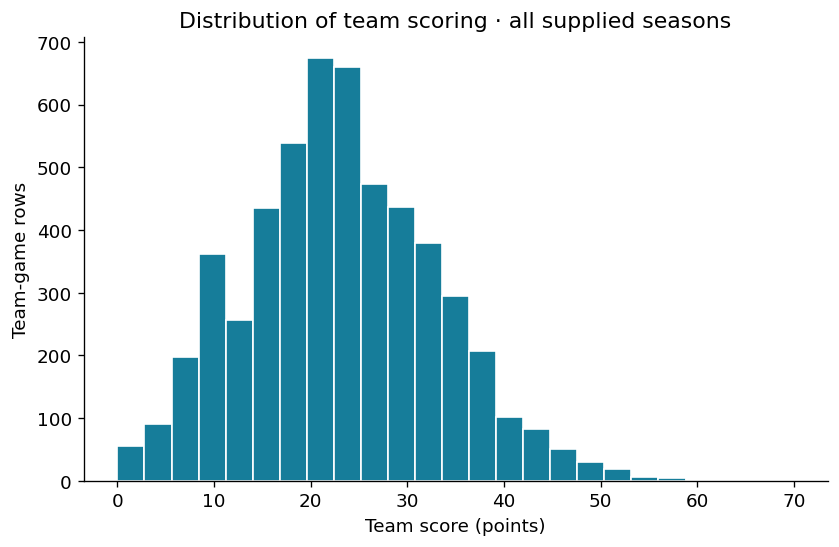

In [4]:
games['score'].plot.hist(bins=25, color='#167D9A', edgecolor='white')
plt.title('Distribution of team scoring · all supplied seasons')
plt.xlabel('Team score (points)'); plt.ylabel('Team-game rows')
plt.show()

**Pause and predict:** what would a model that always predicts the average score miss? Write one observation from the histogram.

### Build inputs that exist before kickoff/tipoff
 A rolling average smooths recent performance. `shift(1)` excludes the current game; the first three games per team-season are skipped. Form resets each season, so no invented history is used for new teams.

 We also join the opponent's prior form. The join uses this game's opponent, but its averages contain only earlier games. **Never remove `shift(1)` to improve accuracy.**

In [5]:
WINDOW = 5  # Keep the guided run at 5; changing it requires rerunning all cells below.
history_stats = ['score', 'allowed', 'win_target'] + ['total_yards', 'opp_total_yards', 'turnovers', 'opp_turnovers']
group = games.groupby(['season', 'team'], sort=False)
for stat in history_stats:
    games['prior_' + stat] = group[stat].transform(
        lambda values: values.shift(1).rolling(WINDOW, min_periods=3).mean())
prior_columns = ['prior_' + stat for stat in history_stats]
opponent_form = games[['game_id', 'team'] + prior_columns].rename(
    columns={'team':'opponent', **{col:'opp_' + col for col in prior_columns}})
model_data = games.merge(opponent_form, on=['game_id', 'opponent'], how='left', validate='many_to_one')
required = ['prior_score', 'prior_allowed', 'opp_prior_score', 'opp_prior_allowed']
model_data = model_data.dropna(subset=required).copy()
FEATURES = ['is_home'] + prior_columns + ['opp_' + col for col in prior_columns]
print(f'Usable prediction rows: {len(model_data):,} / {len(games):,}')
display(model_data[['season','team','opponent'] + FEATURES].head().round(2))

Usable prediction rows: 4,322 / 5,357


,season,team,opponent,is_home,prior_score,prior_allowed,prior_win_target,prior_total_yards,prior_opp_total_yards,prior_turnovers,prior_opp_turnovers,opp_prior_score,opp_prior_allowed,opp_prior_win_target,opp_prior_total_yards,opp_prior_opp_total_yards,opp_prior_turnovers,opp_prior_opp_turnovers
87,2015,BAL,PIT,0,23.33,28.00,0.00,354.67,NaN,1.67,NaN,25.33,17.33,0.67,394.00,NaN,0.67,NaN
88,2015,PIT,BAL,1,25.33,17.33,0.67,394.00,NaN,0.67,NaN,23.33,28.00,0.00,354.67,NaN,1.67,NaN
89,2015,CAR,TB,0,23.67,16.00,1.00,348.00,315.00,0.67,2.00,16.33,26.67,0.33,308.00,348.33,1.67,1.67
90,2015,TB,CAR,1,16.33,26.67,0.33,308.00,348.33,1.67,1.67,23.67,16.00,1.00,348.00,315.00,0.67,2.00
92,2015,DAL,NO,0,25.00,25.00,0.67,380.67,317.00,2.00,1.00,20.00,28.00,0.00,370.33,397.00,2.00,1.00


### Keep future seasons unseen
 Earlier seasons train the model. The second-to-last season is **validation** for your experiments; the last season is the **test**. Both sides of any game stay in the same split. Imputation and scaling learn only from training rows.

 Team-game observations share opponents and history, so they are not independent samples. Metrics are descriptive held-out performance, not confidence intervals.

In [6]:
seasons = sorted(model_data['season'].astype(str).unique())
train = model_data[model_data['season'].astype(str).isin(seasons[:-2])].copy()
validation = model_data[model_data['season'].astype(str) == seasons[-2]].copy()
test = model_data[model_data['season'].astype(str) == seasons[-1]].copy()
assert all(len(frame) > 0 for frame in [train, validation, test])
assert not set(train.game_id) & set(test.game_id)
assert not set(validation.game_id) & set(test.game_id)
for name, frame in [('train', train), ('validation', validation), ('test', test)]:
    print(name, sorted(frame['season'].astype(str).unique()), len(frame), 'rows')

def numeric_pipeline(estimator):
    return make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), estimator)

train ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022'] 3374 rows
validation ['2023'] 474 rows
test ['2024'] 474 rows


## 2. Regression: predict points
 **Concept:** linear regression fits a weighted combination of inputs to a numeric target. Here the target is next-game scoring. MAE is the average absolute error in points; lower is better.

 A model must earn its complexity. Compare it with a baseline that always predicts the **training** mean. Linear predictions can be negative and may miss extreme scores; this is an introductory model, not a betting tool.

In [7]:
regression = numeric_pipeline(LinearRegression())
regression.fit(train[FEATURES], train['score'])
regression_baseline = DummyRegressor(strategy='mean').fit(train[FEATURES], train['score'])
regression_rows = []
for name, frame in [('validation', validation), ('test', test)]:
    for label, estimator in [('Training mean', regression_baseline), ('Linear regression', regression)]:
        prediction = estimator.predict(frame[FEATURES])
        regression_rows.append({'split': name, 'model': label, 'MAE': mean_absolute_error(frame['score'], prediction)})
display(pd.DataFrame(regression_rows).round(3))

,split,model,MAE
0,validation,Training mean,7.999
1,validation,Linear regression,7.616
2,test,Training mean,7.933
3,test,Linear regression,7.405


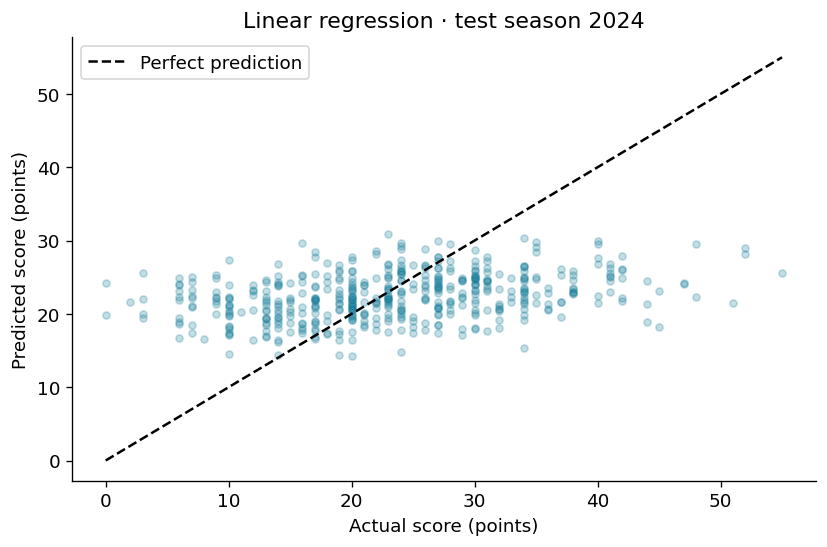

In [8]:
predicted_score = regression.predict(test[FEATURES])
plt.scatter(test['score'], predicted_score, alpha=0.25, s=18, color='#167D9A')
limits = [min(test['score'].min(), predicted_score.min()), max(test['score'].max(), predicted_score.max())]
plt.plot(limits, limits, '--', color='black', label='Perfect prediction')
plt.xlabel('Actual score (points)'); plt.ylabel('Predicted score (points)')
plt.title(f'Linear regression · test season {seasons[-1]}'); plt.legend(); plt.show()

### Your first edit: does home advantage help?
 The code runs as written. Change `USE_HOME` to `False`, rerun this cell, and compare **validation** MAE. Does this one change help? A tiny difference is not proof of a general effect.

In [9]:
USE_HOME = True  # YOUR EDIT
experiment_features = [f for f in FEATURES if USE_HOME or f != 'is_home']
experiment = numeric_pipeline(LinearRegression()).fit(train[experiment_features], train['score'])
print('Validation MAE:', round(mean_absolute_error(validation['score'], experiment.predict(validation[experiment_features])), 3))

Validation MAE: 7.616


**Your interpretation:** state the model MAE, baseline MAE, and whether the model improved on that baseline. Explain the units. What does the scatter plot suggest about extreme scores?

## 3. Classification: predict win or not a win
 **Concept:** logistic regression estimates a probability for a binary category. We predict a win, with draws/ties included in not a win. A threshold turns probability into a decision.

 Accuracy counts correct decisions. Balanced accuracy averages recall across both classes. Precision asks “of predicted wins, how many were wins?” Recall asks “of actual wins, how many did we find?” A confusion matrix shows all four counts. These probabilities are model estimates; we have not established calibration.

validation | majority baseline accuracy: 0.5 | model accuracy: 0.622
test | majority baseline accuracy: 0.5 | model accuracy: 0.686
              precision    recall  f1-score   support

   Not a win       0.68      0.69      0.69       237
         Win       0.69      0.68      0.68       237

    accuracy                           0.69       474
   macro avg       0.69      0.69      0.69       474
weighted avg       0.69      0.69      0.69       474



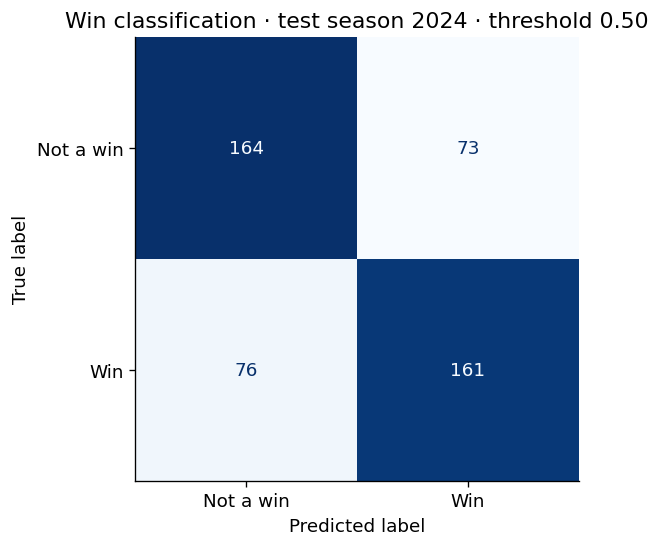

In [10]:
classifier = numeric_pipeline(LogisticRegression(max_iter=1000, random_state=SEED))
classifier.fit(train[FEATURES], train['win_target'])
classification_baseline = DummyClassifier(strategy='most_frequent').fit(train[FEATURES], train['win_target'])
for name, frame in [('validation', validation), ('test', test)]:
    print(name, '| majority baseline accuracy:', round(classification_baseline.score(frame[FEATURES], frame['win_target']), 3),
          '| model accuracy:', round(classifier.score(frame[FEATURES], frame['win_target']), 3))
test_probability = classifier.predict_proba(test[FEATURES])[:, 1]
test_decision = (test_probability >= 0.50).astype(int)
print(classification_report(test['win_target'], test_decision, target_names=['Not a win','Win'], zero_division=0))
ConfusionMatrixDisplay.from_predictions(test['win_target'], test_decision, display_labels=['Not a win','Win'], cmap='Blues', colorbar=False)
plt.title(f'Win classification · test season {seasons[-1]} · threshold 0.50'); plt.show()

### Your second edit: change the threshold
 Change `THRESHOLD` to 0.35 or 0.65. This experiment uses validation games. Before running, predict which errors will increase. Choose settings here; repeated test tuning makes the test less honest.

In [11]:
THRESHOLD = 0.50  # YOUR EDIT: choose a number between 0 and 1
assert 0 < THRESHOLD < 1
validation_probability = classifier.predict_proba(validation[FEATURES])[:, 1]
validation_decision = (validation_probability >= THRESHOLD).astype(int)
print('Validation accuracy:', round(accuracy_score(validation['win_target'], validation_decision), 3))
print('Validation balanced accuracy:', round(balanced_accuracy_score(validation['win_target'], validation_decision), 3))
print(classification_report(validation['win_target'], validation_decision, target_names=['Not a win','Win'], zero_division=0))

Validation accuracy: 0.622
Validation balanced accuracy: 0.622
              precision    recall  f1-score   support

   Not a win       0.62      0.63      0.62       237
         Win       0.62      0.62      0.62       237

    accuracy                           0.62       474
   macro avg       0.62      0.62      0.62       474
weighted avg       0.62      0.62      0.62       474



**Your interpretation:** compare win precision and recall at two thresholds. Which error would matter more to your hypothetical coach, and why? Classification predicts a category; regression predicts a number—even though logistic regression has “regression” in its name.

## 4. Clustering: find similar team-season profiles
 **Concept:** K-Means finds K groups whose standardized feature values are similar. There is no outcome label to predict. Cluster numbers are arbitrary; cluster 0 is not automatically “best.”

 We now summarize the **latest supplied season**, including completed-game statistics. This is retrospective exploration, not a future prediction. Teams with fewer than 10 recorded games are excluded. Missing optional NFL fields are imputed with column medians; inspect the counts. Available statistics describe scoring/results, not complete tactics or player roles.

In [12]:
profile_season = sorted(games['season'].astype(str).unique())[-1]
latest = games[games['season'].astype(str) == profile_season]
profile_stats = ['score', 'allowed', 'margin', 'win_target'] + ['total_yards', 'opp_total_yards', 'turnovers', 'opp_turnovers']
profiles = latest.groupby('team')[profile_stats].mean()
counts = latest.groupby('team').size()
profiles = profiles[counts >= 10].copy()
PROFILE_FEATURES = ['score', 'allowed', 'win_target'] + ['total_yards', 'opp_total_yards', 'turnovers', 'opp_turnovers']
# Margin is shown for interpretation, but omitted from fitting because score/allowed already determine it.
print('Profile season:', profile_season, '| teams:', len(profiles))
display(profiles.round(2).head(10))
display(profiles[PROFILE_FEATURES].isna().sum().to_frame('missing team averages'))
profile_transform = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())
Z = profile_transform.fit_transform(profiles[PROFILE_FEATURES])

Profile season: 2024 | teams: 32


,score,allowed,margin,win_target,total_yards,opp_total_yards,turnovers,opp_turnovers
team,,,,,,,,
ARI,23.53,22.29,1.24,0.47,358.59,342.65,1.18,0.94
ATL,22.88,24.88,-2.00,0.47,370.06,345.53,1.47,1.00
BAL,30.05,21.16,8.89,0.68,425.32,319.37,0.74,0.89
BUF,30.60,21.60,9.00,0.75,361.35,341.00,0.45,1.75
CAR,20.06,31.41,-11.35,0.29,298.12,404.88,1.35,0.94
CHI,18.24,21.76,-3.53,0.29,283.88,354.24,0.88,1.47
CIN,27.76,25.53,2.24,0.53,365.65,348.53,1.24,1.47
CLE,15.18,25.59,-10.41,0.18,301.41,342.12,1.88,0.82
DAL,20.59,27.53,-6.94,0.41,327.59,355.35,1.65,1.29


,missing team averages
score,0
allowed,0
win_target,0
total_yards,0
opp_total_yards,0
turnovers,0
opp_turnovers,0


### Choose K and inspect the groups
 Standardization puts points, yards, and rates on comparable scales. Without it, large numeric units dominate distance. K-Means favors roughly compact groups; these groups are exploratory and may shift with features or K.

In [13]:
K = 3  # YOUR EDIT: try 2 or 4, then rerun clustering and PCA cells
assert 2 <= K < len(profiles)
kmeans = KMeans(n_clusters=K, n_init=20, random_state=SEED)
clusters = kmeans.fit_predict(Z)
clustered_profiles = profiles.assign(cluster=clusters)
print('Silhouette score:', round(silhouette_score(Z, clusters), 3))
print('Higher silhouette suggests tighter/separated groups; it does not prove sports usefulness.')
display(clustered_profiles.groupby('cluster')[profile_stats].mean().round(2))
display(clustered_profiles.reset_index()[['team','cluster']].sort_values(['cluster','team']))

Silhouette score: 0.218
Higher silhouette suggests tighter/separated groups; it does not prove sports usefulness.


,score,allowed,margin,win_target,total_yards,opp_total_yards,turnovers,opp_turnovers
cluster,,,,,,,,
0,21.81,21.21,0.59,0.53,322.66,330.04,1.05,1.25
1,28.76,21.70,7.05,0.70,379.04,330.94,1.02,1.44
2,19.33,25.89,-6.56,0.29,319.20,352.53,1.53,0.97


,team,cluster
0,ARI,0
5,CHI,0
9,DEN,0
12,HOU,0
15,KC,0
16,LA,0
17,LAC,0
19,MIA,0
24,NYJ,0
26,PIT,0


### Less guidance: find your team
 Fill in a team name exactly as it appears in the profile table. Compare it with the others in its cluster. Use the hint only if needed.

 <details><summary>Hint</summary>Use `clustered_profiles.loc[MY_TEAM, 'cluster']`, then filter `clustered_profiles['cluster'] == that_number`.</details>

In [14]:
MY_TEAM = None  # TODO: replace None with a quoted team name / abbreviation
# TODO: display your team's cluster members and compare their statistics.

**Your interpretation:** describe each cluster using its average statistics, then give it a tentative sports name. Does changing K produce a useful extra group, or just split a similar group? Do not infer playing style that the data does not measure.

## 5. Dimensionality reduction: map profiles with PCA
 **Concept:** PCA replaces many standardized variables with new summary axes. PC1 captures the most variation; PC2 captures the most remaining variation at a right angle to PC1. They are weighted mixtures, not original statistics.

 K-Means above used **all** selected standardized features. PCA here provides a 2D display of those profiles; it does not refit the clusters. Nearby points may still differ on dimensions left out of the map.

Two components retain 73.2% of standardized feature variance.


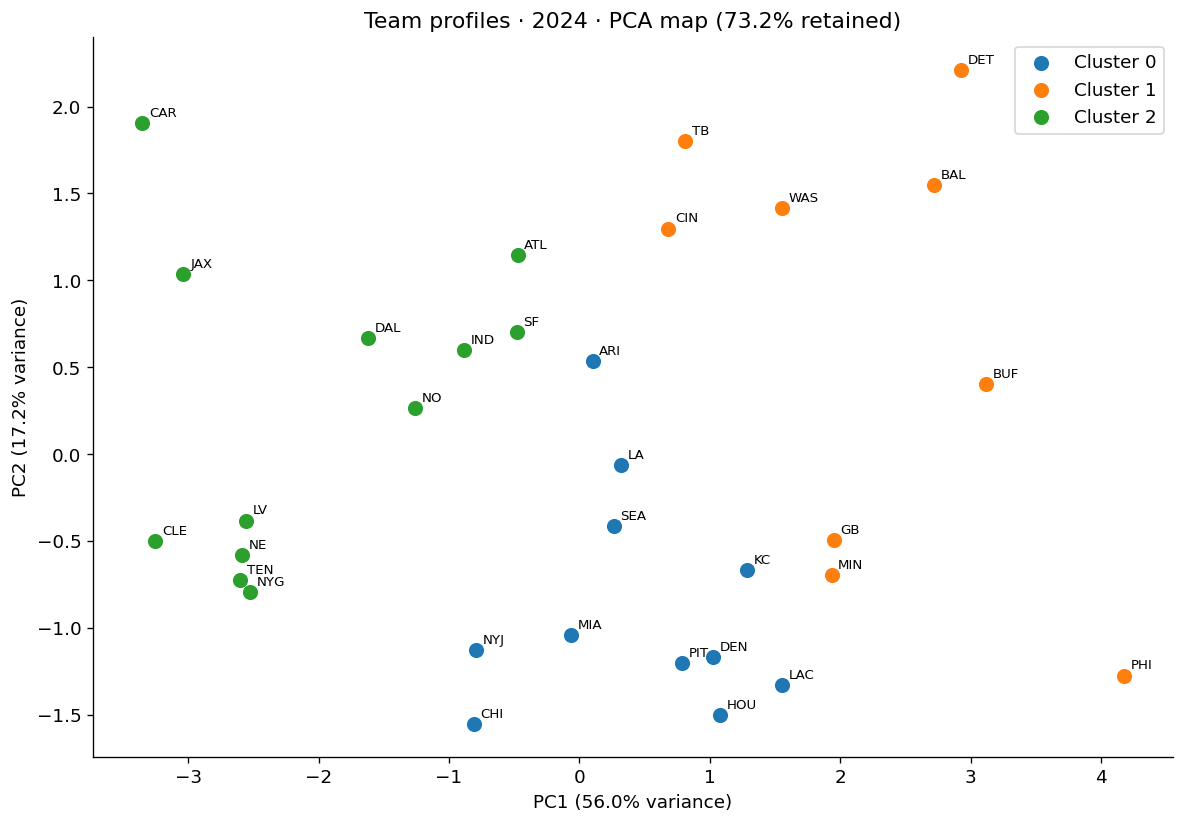

In [15]:
pca = PCA(n_components=2)
coordinates = pca.fit_transform(Z)
retained = pca.explained_variance_ratio_.sum()
print(f'Two components retain {retained:.1%} of standardized feature variance.')
fig, ax = plt.subplots(figsize=(10, 7))
for cluster in range(K):
    mask = clusters == cluster
    ax.scatter(coordinates[mask, 0], coordinates[mask, 1], label=f'Cluster {cluster}', s=65)
for team, xy in zip(profiles.index, coordinates):
    ax.annotate(team, xy, xytext=(4, 4), textcoords='offset points', fontsize=8)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title(f'Team profiles · {profile_season} · PCA map ({retained:.1%} retained)')
ax.legend(); fig.tight_layout(); plt.show()

### Read the new axes
 The weights below show which original standardized features contribute to each axis. Large absolute weights matter more; the sign of a whole PCA axis can flip without changing the geometry. Do not label PC1 “quality” just because it separates teams.

,PC1 weight,PC2 weight
score,0.437,0.426
allowed,-0.390,0.439
win_target,0.471,0.090
total_yards,0.354,0.550
opp_total_yards,-0.257,0.483
turnovers,-0.355,0.100
opp_turnovers,0.342,-0.270


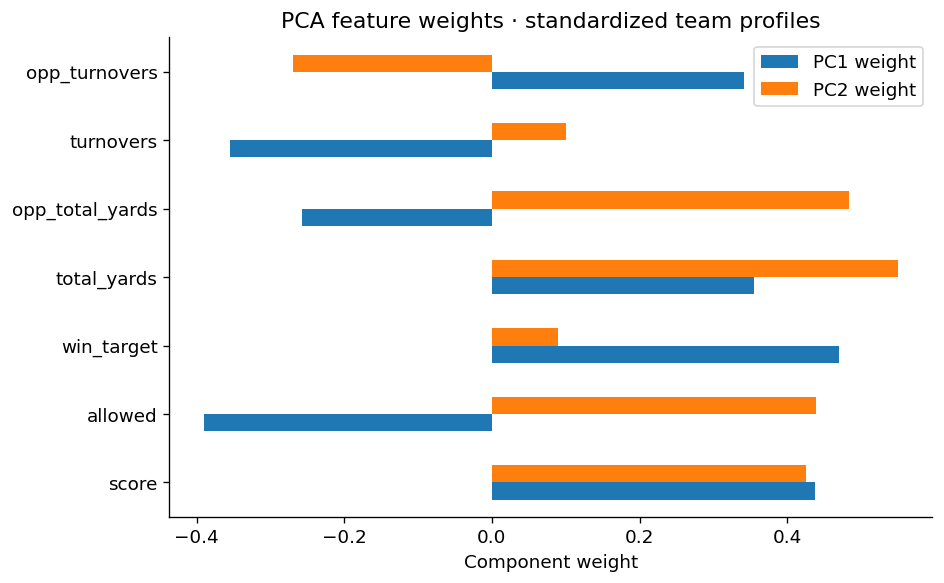

In [16]:
weights = pd.DataFrame(pca.components_.T, index=PROFILE_FEATURES, columns=['PC1 weight','PC2 weight'])
display(weights.round(3))
weights.plot.barh(figsize=(8, 5))
plt.title('PCA feature weights · standardized team profiles')
plt.xlabel('Component weight'); plt.tight_layout(); plt.show()

### Now you write the calculation
 Calculate the fraction of variance **not** shown in the 2D map. Then name two nearby teams and compare their original statistics.
 <details><summary>Hint</summary>The omitted fraction is `1 - retained`. The profile table still contains the original units.</details>

In [17]:
# TODO: calculate omitted variance and print it as a percentage.
# TODO: select two teams from profiles and compare their original statistics.

## 6. CYOA: your question, your evidence
 Choose a path or invent your own. Do prior yards or prior turnovers add more predictive value? Which profiles gain many yards without scoring many points?

 | Path | Build | Evidence to report |
 |---|---|---|
 | Predict a number | Try a smaller feature list or change the history window | Validation MAE versus the training-mean baseline |
 | Predict a category | Choose inputs and a decision threshold | Validation confusion matrix, precision and recall |
 | Discover groups | Choose profile features and K | Cluster means, members and a reason for your choice |
 | Simplify profiles | Change profile features and repeat PCA | Variance retained, feature weights and a labeled map |

 Start from the provided variables, but write your own cells below. If you change `WINDOW`, rerun preparation and everything after it. If you change profile features, rebuild `Z`, K-Means and PCA together.

 **Prediction rule:** make choices on validation; lock them before a final test evaluation. The guided test results are already visible, so for a genuinely new project use a fresh future holdout. **Exploration rule:** say which season/population you summarized and explain what the available columns cannot tell you.

### Your plan
 **Question:** …

 **Method and why:** …

 **Inputs / target or profile features:** …

 **One change to compare:** …

 **What would count as useful evidence?** …

In [18]:
# YOUR CODE: Prepare your experiment

In [19]:
# YOUR CODE: Fit or transform

In [20]:
# YOUR CODE: Evaluate and visualize

### Your sports story
 Write 3–4 bullets, following Workshop 1's storytelling format:

 - **Question and result:** what did you find? Include a computed number.
 - **Evidence:** which baseline, table or chart supports it?
 - **Sports meaning:** what might a coach or analyst learn?
 - **Limitation / next step:** what remains uncertain? Association is not causation.

 ### Checks before sharing
 - All four methods have been run and interpreted.
 - Prediction inputs contain only information available before the game.
 - You report baseline performance, even if the model fails to improve it.
 - Your PCA story mentions retained variance; your cluster names are interpretations.
 - Your notebook runs from the top with the supplied CSV and your final edits.

 ## Next steps
 Add richer verified features, compare a different model, or test another season. Keep your question and prediction time explicit before adding complexity.